# 08 — Results synthesis

Synthesize rolling forecast credibility, exact portfolio risk, controlled simulations, and degradation under shifted realized processes. The one-shot long-horizon tables are retained only as diagnostics; the rolling-origin tables are the primary empirical evidence.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
CACHE = ROOT / 'results/notebook_cache'
CACHE.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

In [2]:
rolling = pd.read_csv(CACHE / 'rolling_evaluation.csv')
portfolio = pd.read_csv(CACHE / 'portfolio_evaluation.csv')
simulation = pd.read_csv(CACHE / 'simulation_results.csv')
stress = pd.read_csv(CACHE / 'shifted_realization_stress.csv')

display(rolling.sort_values(['horizon', 'energy_score']))
display(portfolio.sort_values('portfolio_mae'))
display(simulation.sort_values(['dgp', 'energy_score']))

,innovation_model,horizon,n_origins,avg_coverage,avg_width,ece,pit_deviation,crps,energy_score,interval_score,abs_coverage_error
9,block_bootstrap,1,47,0.946809,0.055378,0.082270,0.028085,0.006943,0.016720,0.064889,0.046809
6,bootstrap,1,47,0.952128,0.054662,0.084043,0.025745,0.006972,0.016755,0.061962,0.052128
18,cdi_var,1,47,0.914894,0.046844,0.046809,0.024468,0.007021,0.016840,0.058677,0.014894
15,diffusion,1,47,0.957447,0.055892,0.112411,0.037234,0.007126,0.017090,0.063562,0.057447
12,volatility_bootstrap,1,47,0.968085,0.060463,0.124823,0.039362,0.007155,0.017147,0.066699,0.068085
3,student_t,1,47,0.952128,0.058848,0.110638,0.038298,0.007179,0.017187,0.065942,0.052128
0,gaussian,1,47,0.973404,0.062690,0.146099,0.049787,0.007470,0.017788,0.068399,0.073404
10,block_bootstrap,5,47,0.925532,0.055262,0.046809,0.018511,0.007697,0.018530,0.065287,0.025532
7,bootstrap,5,47,0.930851,0.056150,0.046809,0.019362,0.007698,0.018533,0.066381,0.030851
19,cdi_var,5,47,0.914894,0.048257,0.030851,0.017021,0.007762,0.018653,0.063509,0.014894


,innovation_model,horizon,n_origins,portfolio_coverage,portfolio_interval_width,portfolio_mae,portfolio_var_breach_rate
3,block_bootstrap,20,47,0.978723,0.185935,0.029988,0.000000
0,gaussian,20,47,0.978723,0.184813,0.031405,0.021277
2,bootstrap,20,47,0.957447,0.181306,0.031430,0.042553
1,student_t,20,47,0.936170,0.185800,0.031638,0.063830
4,volatility_bootstrap,20,47,1.000000,0.184281,0.032283,0.000000
6,cdi_var,20,47,0.893617,0.126918,0.033989,0.042553
5,diffusion,20,47,0.914894,0.156579,0.034842,0.042553


,dgp,forecast_model,innovation_model,avg_coverage,avg_width,energy_score,crps,interval_score,ece,pit_deviation,...,width_1,coverage_2,width_2,coverage_3,width_3,coverage_4,width_4,nominal_coverage,coverage_error,abs_coverage_error
1,gaussian,VAR,student_t,0.8900,3.310989,1.383937,0.589557,4.563696,0.030833,0.0180,...,2.938031,0.86,2.947686,0.93,3.576028,0.91,3.782211,0.9,-0.0100,0.0100
2,gaussian,VAR,bootstrap,0.8800,3.462249,1.392267,0.591263,4.619466,0.019167,0.0150,...,3.004081,0.85,3.007839,0.91,3.844497,0.92,3.992580,0.9,-0.0200,0.0200
0,gaussian,VAR,gaussian,0.8950,3.454778,1.398041,0.596534,4.600461,0.008333,0.0175,...,3.049171,0.86,3.049414,0.91,3.765237,0.96,3.955289,0.9,-0.0050,0.0050
3,gaussian,VAR,block_bootstrap,0.8850,3.369893,1.399063,0.594286,4.533786,0.006667,0.0150,...,3.238253,0.82,2.808064,0.91,3.632806,0.91,3.800450,0.9,-0.0150,0.0150
4,gaussian,VAR,volatility_bootstrap,0.9450,4.533221,1.420645,0.605665,5.009826,0.065833,0.0210,...,3.858732,0.97,4.881139,0.90,3.928756,0.99,5.464256,0.9,0.0450,0.0450
18,heteroskedastic,VAR,block_bootstrap,0.9025,6.325420,1.925421,0.823623,8.681762,0.006667,0.0090,...,6.450587,0.90,6.183084,0.91,5.846746,0.91,6.821262,0.9,0.0025,0.0025
17,heteroskedastic,VAR,bootstrap,0.8950,6.089915,1.942438,0.834043,8.622385,0.033333,0.0200,...,6.572911,0.87,5.708287,0.90,5.772695,0.89,6.305768,0.9,-0.0050,0.0050
16,heteroskedastic,VAR,student_t,0.8875,5.582867,2.003434,0.856605,8.445885,0.081667,0.0515,...,5.567428,0.90,5.876020,0.91,5.089139,0.89,5.798880,0.9,-0.0125,0.0125
15,heteroskedastic,VAR,gaussian,0.8950,5.855341,2.053411,0.875292,8.280790,0.095000,0.0570,...,5.843226,0.90,6.181138,0.91,5.324197,0.89,6.072805,0.9,-0.0050,0.0050
19,heteroskedastic,VAR,volatility_bootstrap,0.9275,7.402131,2.066689,0.880186,8.649174,0.106667,0.0565,...,8.699840,0.89,6.825056,0.94,7.074876,0.94,7.008753,0.9,0.0275,0.0275


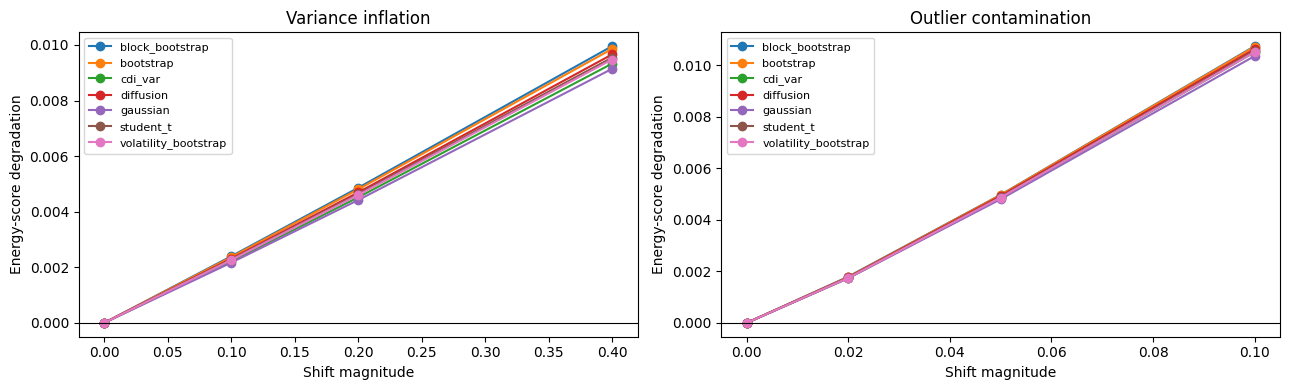

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (method, model), group in stress.groupby(['shift_method', 'innovation_model']):
    axis = axes[0] if method == 'variance_inflation' else axes[1]
    axis.plot(group['epsilon'], group['energy_score_change'], marker='o', label=model)
for axis, title in zip(axes, ['Variance inflation', 'Outlier contamination']):
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set(xlabel='Shift magnitude', ylabel='Energy-score degradation', title=title)
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Interpretation checklist

- Prefer models that jointly improve proper scores, calibration, and sharpness across rolling origins.
- Treat portfolio VaR breach rates near the nominal 5% as credible; wider intervals alone are not a win.
- Check whether rankings persist across horizons, simulated regimes, and seeds in notebook 09.
- Report the rate of degradation under shift, not only nominal performance.
- If DI-VAR does not consistently beat the interpretable baselines, that is a substantive result rather than a failed experiment.